# 📈 Forecasting TRM (USD/COP) — Fase 2: Modelos Base
**Basado en:** Forecasting: Principles and Practice, the Pythonic Way — Capítulos 5 y 8

**Objetivo:** Establecer una línea base (benchmark) con tres modelos simples: Naive, Drift y ETS. Entrenaremos con datos hasta 2024 y compararemos los pronósticos contra lo que realmente ocurrió en 2025-2026.

> 💡 **¿Por qué empezar con modelos simples?**
> El libro es claro en esto: un modelo complejo que no supera a un Naive es un modelo inútil. Antes de usar ARIMA o redes neuronales, hay que saber cuál es el piso mínimo de desempeño.

---

## 0. Instalación de librerías

In [1]:
%pip install statsforecast yfinance pandas matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsforecast import StatsForecast
from statsforecast.models import Naive, RandomWalkWithDrift, SimpleExponentialSmoothing, AutoETS

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 2. Cargar datos (de la Fase 1)

Volvemos a descargar los datos limpios con yfinance, aplicando el mismo filtro de outliers que usamos en la Fase 1.

In [3]:
import yfinance as yf

print('📥 Descargando datos TRM desde Yahoo Finance...')
raw = yf.download('COP=X', start='2016-01-01', end='2026-05-31', auto_adjust=True, progress=False)
df = raw[['Close']].reset_index()
df.columns = ['fecha', 'trm']
df['fecha'] = pd.to_datetime(df['fecha']).dt.tz_localize(None)
df = df.dropna().sort_values('fecha').reset_index(drop=True)

# Mismo filtro de outliers de la Fase 1
retornos = df['trm'].pct_change().abs() * 100
outliers = (retornos > 15).sum()
if outliers > 0:
    df = df[retornos <= 15].reset_index(drop=True)
    print(f'⚠️  Se filtraron {outliers} registro(s) con cambios diarios irreales')

print(f'✅ {len(df):,} registros cargados')
print(f'   Período completo: {df["fecha"].min().date()} → {df["fecha"].max().date()}')
df.tail(3)

📥 Descargando datos TRM desde Yahoo Finance...
⚠️  Se filtraron 2 registro(s) con cambios diarios irreales
✅ 2,707 registros cargados
   Período completo: 2016-01-04 → 2026-05-29


,fecha,trm
2704,2026-05-27,3672.189941
2705,2026-05-28,3635.659912
2706,2026-05-29,3651.300049


## 3. Preparar datos mensuales y dividir train / test

> 📖 **Concepto del libro (Cap. 5):** Para evaluar un modelo de forecasting, nunca se entrena y evalúa con los mismos datos. Se separa una parte para **entrenamiento** (train) y otra para **evaluación** (test). El modelo nunca ve el test durante el entrenamiento — es como un examen sorpresa.
>
> En nuestro caso: **train = 2016 a 2024**, **test = 2025 a 2026** (lo que ya ocurrió en la realidad).

In [4]:
# Convertir a datos mensuales (promedio del mes)
df_mensual = (
    df.set_index('fecha')['trm']
    .resample('MS')
    .mean()
    .reset_index()
    .rename(columns={'fecha': 'ds', 'trm': 'y'})
)
df_mensual['unique_id'] = 'TRM_USDCOP'

# División train / test
corte = pd.to_datetime('2025-01-01')
train = df_mensual[df_mensual['ds'] < corte].copy()
test  = df_mensual[df_mensual['ds'] >= corte].copy()

horizonte = len(test)  # meses a pronosticar

print('📊 DIVISIÓN DE DATOS')
print('=' * 40)
print(f'Train: {train["ds"].min().date()} → {train["ds"].max().date()} ({len(train)} meses)')
print(f'Test:  {test["ds"].min().date()}  → {test["ds"].max().date()}  ({len(test)} meses)')
print(f'Horizonte de pronóstico: {horizonte} meses')

📊 DIVISIÓN DE DATOS
Train: 2016-01-01 → 2024-12-01 (108 meses)
Test:  2025-01-01  → 2026-05-01  (17 meses)
Horizonte de pronóstico: 17 meses


### 🔍 Pregunta previa — Antes de ver los modelos

> Responde esto **antes de correr las siguientes celdas**. Es importante que registres tu intuición antes de ver los resultados.

1. ¿Por qué crees que usamos datos **mensuales** en lugar de diarios para construir los modelos?
2. Tenemos 9 años de datos de entrenamiento (2016-2024). ¿Te parece suficiente o poco? ¿Por qué?
3. El test cubre 2025-2026. ¿Qué eventos económicos o políticos ocurrieron en ese período que podrían hacer difícil el pronóstico?
4. Antes de ver los resultados: ¿cuál de los tres modelos (Naive, Drift, ETS) crees que va a funcionar mejor para la TRM? Argumenta con lo que aprendiste en la Fase 1.

---

## 4. Visualizar el corte train / test

Antes de modelar, siempre es útil ver visualmente dónde está la división.

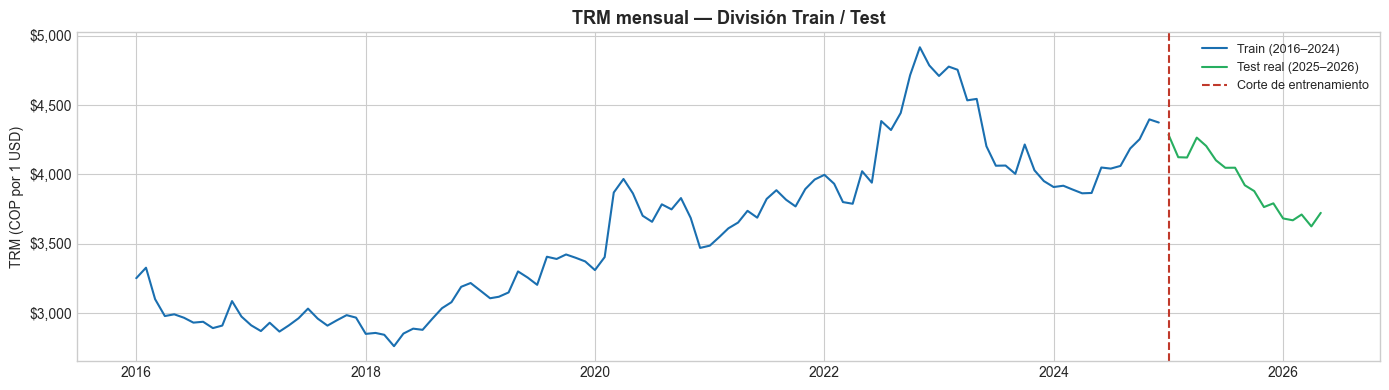

✅ Guardado como 05_train_test_split.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train['ds'], train['y'], color='#1a6fb0', linewidth=1.5, label='Train (2016–2024)')
ax.plot(test['ds'],  test['y'],  color='#27ae60', linewidth=1.5, label='Test real (2025–2026)')
ax.axvline(corte, color='#c0392b', linewidth=1.5, linestyle='--', label='Corte de entrenamiento')

ax.set_title('TRM mensual — División Train / Test', fontsize=13, fontweight='bold')
ax.set_ylabel('TRM (COP por 1 USD)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('05_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado como 05_train_test_split.png')

## 5. Entrenar los tres modelos base

> 📖 **Los tres modelos (Cap. 5 y 8):**
>
> - **Naive:** El pronóstico para cualquier período futuro es igual al último valor observado. Predice que mañana = hoy.
> - **Drift (RandomWalkWithDrift):** Extiende la tendencia promedio observada en todo el período de entrenamiento. Traza una línea recta desde el último valor.
> - **ETS (Suavización Exponencial):** Da más peso a los datos recientes y menos a los datos antiguos. Se adapta gradualmente a los cambios de nivel de la serie.

In [6]:
# Definir los modelos
modelos = StatsForecast(
    models=[
        Naive(),
        RandomWalkWithDrift(),
        AutoETS(season_length=12),
    ],
    freq='MS',  # frecuencia mensual
    n_jobs=-1
)

# Entrenar y pronosticar
print('⚙️  Entrenando modelos...')
forecast = modelos.forecast(df=train, h=horizonte, level=[80, 95])
forecast = forecast.reset_index()

print('✅ Modelos entrenados y pronóstico generado')
print(f'   Columnas disponibles: {list(forecast.columns)}')
forecast.head()

# Ver nombres exactos de columnas
print('Columnas del forecast:')
print(list(forecast.columns))


⚙️  Entrenando modelos...
✅ Modelos entrenados y pronóstico generado
   Columnas disponibles: ['index', 'unique_id', 'ds', 'Naive', 'Naive-lo-80', 'Naive-lo-95', 'Naive-hi-80', 'Naive-hi-95', 'RWD', 'RWD-lo-80', 'RWD-lo-95', 'RWD-hi-80', 'RWD-hi-95', 'AutoETS', 'AutoETS-lo-95', 'AutoETS-lo-80', 'AutoETS-hi-80', 'AutoETS-hi-95']
Columnas del forecast:
['index', 'unique_id', 'ds', 'Naive', 'Naive-lo-80', 'Naive-lo-95', 'Naive-hi-80', 'Naive-hi-95', 'RWD', 'RWD-lo-80', 'RWD-lo-95', 'RWD-hi-80', 'RWD-hi-95', 'AutoETS', 'AutoETS-lo-95', 'AutoETS-lo-80', 'AutoETS-hi-80', 'AutoETS-hi-95']


## 6. Visualizar pronósticos vs realidad

> 📖 **Concepto clave:** Los intervalos de predicción (bandas sombreadas) muestran el rango donde el modelo espera que caiga el valor real con cierta probabilidad. Una banda del 95% debería contener el valor real el 95% de las veces — si no lo hace, el modelo está mal calibrado.

Columnas de modelos detectadas: ['Naive', 'RWD', 'AutoETS']


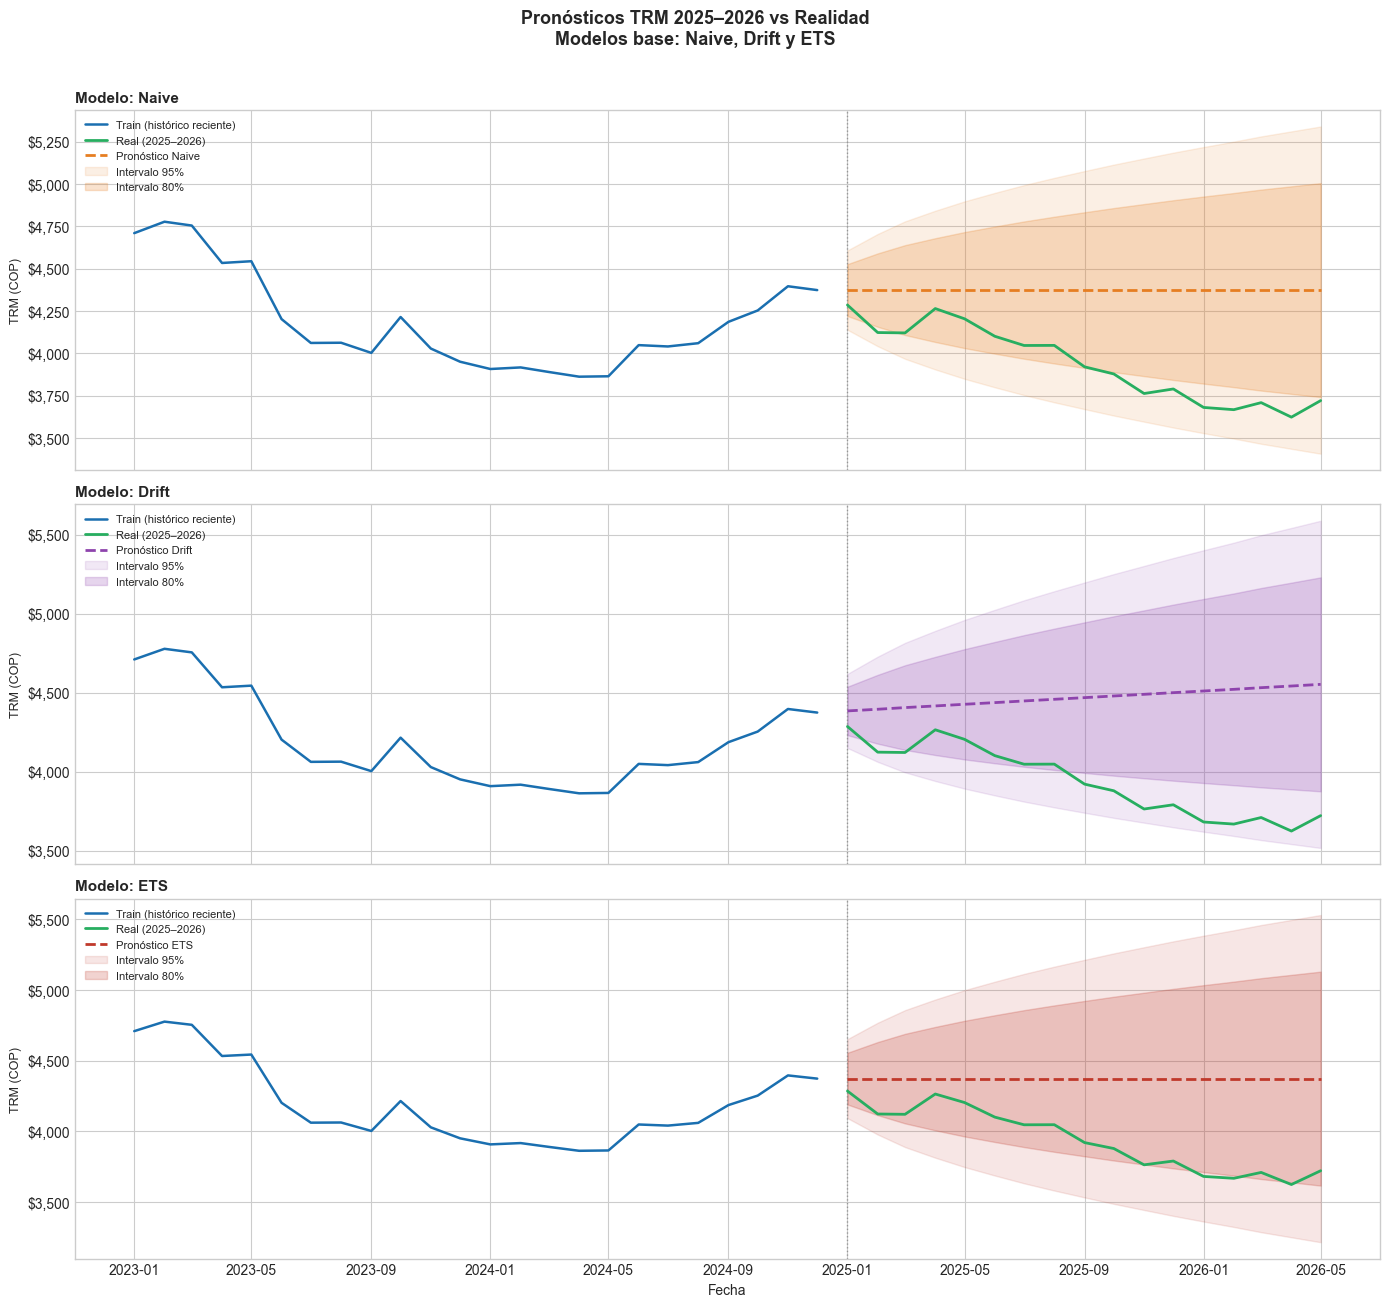

✅ Guardado como 06_pronosticos_modelos_base.png


In [7]:
# Detectar nombres reales de columnas generadas por statsforecast
cols_base = [c for c in forecast.columns if c not in ['unique_id', 'ds', 'index', 'y']
             and not any(s in c for s in ['-lo-', '-hi-'])
             and pd.api.types.is_numeric_dtype(forecast[c])]
print(f'Columnas de modelos detectadas: {cols_base}')

def get_label_color(col):
    """Identifica el modelo real sin importar el nombre exacto que use la librería"""
    c = col.lower()
    if 'drift' in c or 'rwd' in c or ('walk' in c and 'drift' in c):
        return ('Drift', '#8e44ad')
    if 'ets' in c:
        return ('ETS', '#c0392b')
    if 'naive' in c:
        return ('Naive', '#e67e22')
    return (col, '#1a6fb0')

fig, axes = plt.subplots(len(cols_base), 1, figsize=(14, 4.3*len(cols_base)), sharex=True)
if len(cols_base) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_base):
    label, color = get_label_color(col)
    contexto = train[train['ds'] >= '2023-01-01']
    ax.plot(contexto['ds'], contexto['y'],
            color='#1a6fb0', linewidth=1.8, label='Train (histórico reciente)')
    ax.plot(test['ds'], test['y'],
            color='#27ae60', linewidth=2, label='Real (2025–2026)', zorder=5)
    ax.plot(forecast['ds'], forecast[col],
            color=color, linewidth=2, linestyle='--', label=f'Pronóstico {label}', zorder=4)

    lo95, hi95 = f'{col}-lo-95', f'{col}-hi-95'
    if lo95 in forecast.columns and hi95 in forecast.columns:
        ax.fill_between(forecast['ds'], forecast[lo95], forecast[hi95],
                        color=color, alpha=0.12, label='Intervalo 95%')
    lo80, hi80 = f'{col}-lo-80', f'{col}-hi-80'
    if lo80 in forecast.columns and hi80 in forecast.columns:
        ax.fill_between(forecast['ds'], forecast[lo80], forecast[hi80],
                        color=color, alpha=0.22, label='Intervalo 80%')

    ax.axvline(corte, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.set_title(f'Modelo: {label}', fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('TRM (COP)', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Fecha', fontsize=10)
fig.suptitle('Pronósticos TRM 2025–2026 vs Realidad\nModelos base: Naive, Drift y ETS',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_pronosticos_modelos_base.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado como 06_pronosticos_modelos_base.png')


### 🔍 Sección A — ¿Qué observas en los pronósticos?

> Responde antes de ver las métricas numéricas de la siguiente sección.

---

#### 👁️ Nivel 1: Observación directa

1. Mira el gráfico del modelo **Naive**. ¿Cómo se ve su pronóstico visualmente? ¿Es una línea plana, una curva, sube, baja?
2. Mira el gráfico del modelo **Drift**. ¿Hacia dónde apunta su pronóstico? ¿Coincide con lo que realmente ocurrió?
3. Mira el gráfico del modelo **ETS**. ¿Se parece más al Naive o al Drift? ¿Qué diferencia notas?
4. En los tres gráficos, ¿la línea verde (realidad) queda dentro de las bandas sombreadas (intervalos de predicción) o se sale? ¿En cuál modelo se sale más?

---

#### 🧠 Nivel 2: Interpretación

5. El modelo Naive pronostica que el dólar se queda igual. ¿Cuándo sería ese un buen supuesto? ¿Cuándo sería terrible?
6. El modelo Drift usó la tendencia de **todo el período 2016-2024** para proyectar hacia adelante. Si la tendencia de ese período fue alcista (el dólar subió), ¿hacia dónde apuntará el Drift? ¿Eso refleja bien lo que pasó en 2025-2026?
7. Si el valor real (línea verde) se sale constantemente por encima de las bandas de predicción, ¿qué significa eso para el modelo? ¿Y si se sale constantemente por debajo?
8. ¿Cuál de los tres modelos capturó mejor la dirección general del movimiento de la TRM en 2025-2026, aunque no acertara el valor exacto?

---

#### 💼 Nivel 3: Pensamiento crítico

9. El Naive es el modelo más simple posible. Si en la siguiente sección resulta que tiene mejor desempeño que el ETS, ¿qué nos dice eso sobre la naturaleza de la TRM como serie temporal?
10. Un modelo que siempre subestima (predice menos de lo real) tiene un **sesgo sistemático**. ¿Ves evidencia de sesgo en alguno de los tres modelos mirando los gráficos?
11. Las bandas sombreadas se ensanchan con el tiempo (hacia la derecha). ¿Por qué crees que pasa eso? ¿Tiene sentido económicamente?
12. Si fueras a presentar estos resultados a un gerente de una empresa importadora, ¿cuál de los tres modelos usarías para tomar decisiones de cobertura cambiaria, y por qué? (No hay respuesta única correcta — el argumento es lo que importa.)

---

## 7. Métricas de error

> 📖 **Concepto del libro (Cap. 5):** Las métricas de error cuantifican qué tan lejos estuvo el pronóstico de la realidad. Las principales:
>
> - **MAE (Mean Absolute Error):** Error promedio en pesos. Fácil de interpretar: si MAE = $200, el modelo se equivocó en promedio $200 por mes.
> - **RMSE (Root Mean Squared Error):** Penaliza más los errores grandes. Si el modelo falla mucho un mes puntual, el RMSE lo refleja más que el MAE.
> - **MAPE (Mean Absolute Percentage Error):** Error en porcentaje. Útil para comparar modelos entre series con escalas distintas.

In [8]:
# Unir pronósticos con valores reales
comparacion = forecast.merge(test[['ds', 'y']], on='ds', how='inner')

# Filtrar SOLO columnas numéricas que correspondan a modelos reales
# (excluye 'index', 'unique_id', 'ds', 'y', y cualquier columna no numérica)
cols_base = [c for c in cols_base if c not in ['index', 'unique_id', 'ds', 'y']
             and pd.api.types.is_numeric_dtype(forecast[c])]
print(f'Columnas de modelo válidas tras filtrar: {cols_base}')

# Diagnóstico: ¿son realmente iguales Naive y AutoETS, o es coincidencia de redondeo?
print()
print('🔍 DIAGNÓSTICO — primeros 5 valores de cada modelo:')
print(forecast[['ds'] + cols_base].head(5).to_string())
print()

resultados = []
for col in cols_base:
    label, _ = get_label_color(col)
    y_real = comparacion['y']
    y_pred = comparacion[col]
    errores = y_real - y_pred
    mae  = errores.abs().mean()
    rmse = np.sqrt((errores**2).mean())
    mape = (errores.abs() / y_real * 100).mean()
    sesgo = errores.mean()
    resultados.append({'Modelo': label, 'Columna_real': col, 'MAE ($)': mae, 'RMSE ($)': rmse,
                       'MAPE (%)': mape, 'Sesgo ($)': sesgo})

df_resultados_full = pd.DataFrame(resultados)
print('📋 Tabla completa (con nombre de columna original, para verificar):')
print(df_resultados_full.to_string(index=False))
print()

df_resultados = df_resultados_full.drop(columns=['Columna_real']).set_index('Modelo').round(2)

print('📊 TABLA DE MÉTRICAS DE ERROR')
print('=' * 55)
print(df_resultados.to_string())
print()
mejor = df_resultados['MAE ($)'].idxmin()
print(f'🏆 Mejor modelo por MAE: {mejor} (${df_resultados.loc[mejor, "MAE ($)"]:.2f} de error promedio mensual)')


Columnas de modelo válidas tras filtrar: ['Naive', 'RWD', 'AutoETS']

🔍 DIAGNÓSTICO — primeros 5 valores de cada modelo:
          ds        Naive          RWD      AutoETS
0 2025-01-01  4373.969793  4384.466988  4373.972059
1 2025-02-01  4373.969793  4394.964182  4373.972059
2 2025-03-01  4373.969793  4405.461377  4373.972059
3 2025-04-01  4373.969793  4415.958571  4373.972059
4 2025-05-01  4373.969793  4426.455766  4373.972059

📋 Tabla completa (con nombre de columna original, para verificar):
Modelo Columna_real    MAE ($)   RMSE ($)  MAPE (%)   Sesgo ($)
 Naive        Naive 435.139617 486.739287 11.387824 -435.139617
 Drift          RWD 529.614367 593.263707 13.862354 -529.614367
   ETS      AutoETS 435.141883 486.741313 11.387881 -435.141883

📊 TABLA DE MÉTRICAS DE ERROR
        MAE ($)  RMSE ($)  MAPE (%)  Sesgo ($)
Modelo                                        
Naive    435.14    486.74     11.39    -435.14
Drift    529.61    593.26     13.86    -529.61
ETS      435.14    486.74

## 8. Gráfico comparativo de errores

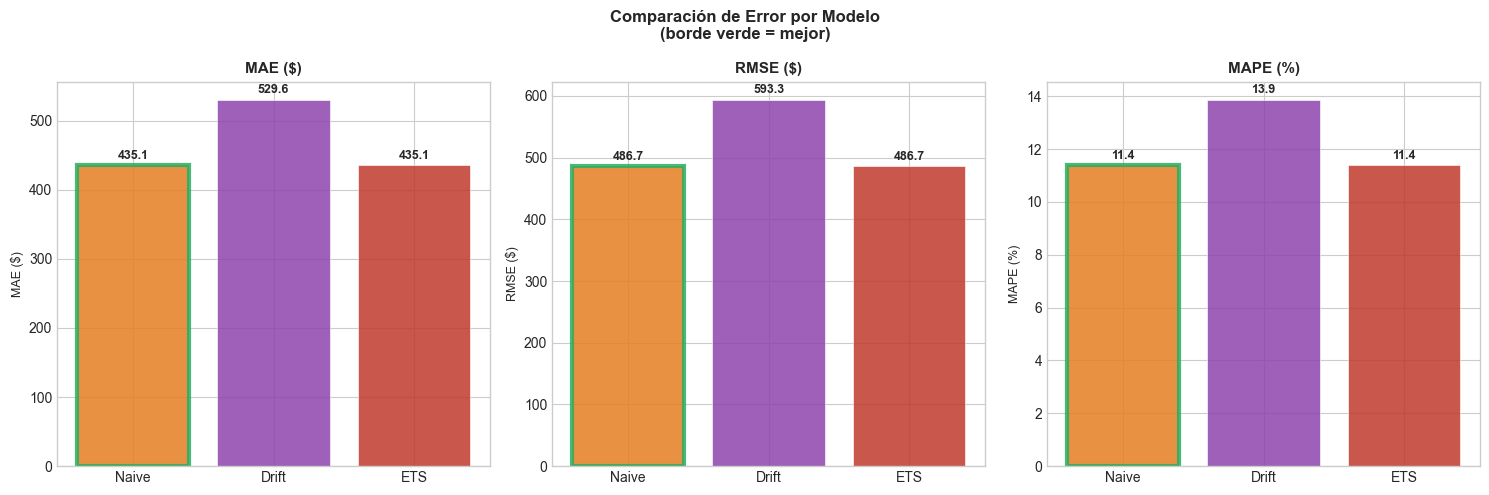

✅ Guardado como 07_comparacion_errores.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = ['MAE ($)', 'RMSE ($)', 'MAPE (%)']
colores_barras = ['#e67e22', '#8e44ad', '#c0392b'][:len(df_resultados)]

for ax, metrica in zip(axes, metricas):
    valores = df_resultados[metrica]
    bars = ax.bar(valores.index, valores.values,
                  color=colores_barras, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=9)
    min_idx = valores.values.argmin()
    bars[min_idx].set_edgecolor('#27ae60')
    bars[min_idx].set_linewidth(3)
    for bar, val in zip(bars, valores.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Comparación de Error por Modelo\n(borde verde = mejor)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('07_comparacion_errores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado como 07_comparacion_errores.png')


## 9. Error mensual por modelo (¿en qué meses fallaron más?)

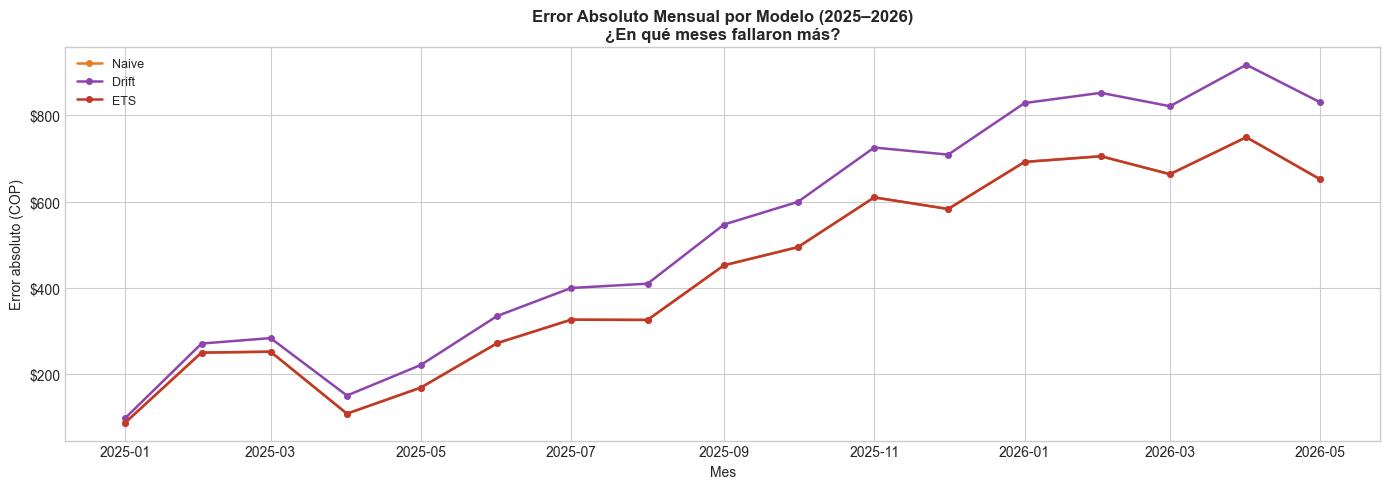

✅ Guardado como 08_error_mensual.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
colores_mod = ['#e67e22', '#8e44ad', '#c0392b']

for col, color in zip(cols_base, colores_mod):
    label, _ = get_label_color(col)
    error_abs = (comparacion['y'] - comparacion[col]).abs()
    ax.plot(comparacion['ds'], error_abs,
            color=color, linewidth=1.8, marker='o', markersize=4, label=label)

ax.set_title('Error Absoluto Mensual por Modelo (2025–2026)\n¿En qué meses fallaron más?',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Error absoluto (COP)', fontsize=10)
ax.set_xlabel('Mes', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('08_error_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado como 08_error_mensual.png')


### 🔍 Sección B — ¿Qué nos dicen las métricas?

---

#### 👁️ Nivel 1: Lectura de resultados

1. ¿Cuál modelo tuvo el MAE más bajo? ¿Cuántos pesos colombianos se equivocó en promedio por mes?
2. ¿El modelo con mejor MAE también tiene el mejor RMSE? Si no coinciden, ¿qué sugiere esa diferencia?
3. Mira la columna **Sesgo**. ¿Algún modelo tiene sesgo positivo (subestima) o negativo (sobreestima)? ¿Cuál y por cuánto?
4. En el gráfico de error mensual, ¿hay meses donde todos los modelos fallaron mucho al mismo tiempo? ¿A qué lo atribuyes?

---

#### 🧠 Nivel 2: Interpretación

5. Si el MAPE de un modelo es del 5%, ¿qué significa en términos prácticos para una empresa que necesita comprar dólares por valor de $1.000 millones de pesos?
6. Un modelo con MAE bajo pero sesgo alto (siempre se equivoca en la misma dirección) puede ser peligroso. ¿Por qué? ¿Qué decisiones incorrectas podría llevar a tomar?
7. El error mensual varía: algunos meses el modelo es muy preciso y otros falla mucho. ¿Esto habla bien o mal del modelo? ¿Qué tan útil es el MAE promedio si el error es tan inconsistente mes a mes?
8. Compara el MAE del mejor modelo con la desviación estándar diaria que calculamos en la Fase 1 (±1.05%). ¿Son consistentes esos dos números? ¿Qué nos dicen juntos sobre la predictibilidad de la TRM?

---

#### 💼 Nivel 3: Conclusiones para el portafolio

9. Si el Naive resultó ser el mejor o uno de los mejores modelos, ¿qué le dirías a alguien que quiere usar machine learning avanzado para predecir la TRM? ¿Cuál sería tu argumento?
10. **Pregunta de entrevista real:** *'¿Cómo justificas usar un modelo tan simple como el Naive en producción?'* Construye una respuesta sólida basada en los resultados que tienes.
11. ¿Cuál es la limitación más importante que comparten los tres modelos de esta fase? ¿Qué tipo de información no están usando que podría mejorar los pronósticos?
12. Si tuvieras que elegir **un solo número** de toda esta fase para presentarle a un gerente no técnico que resume qué tan útil es el mejor modelo, ¿cuál sería y cómo lo explicarías en una frase?

---

## 10. Exportar resultados para la Fase 3

In [11]:
# Guardar datos para la Fase 3 (ARIMA)
df_mensual.to_csv('trm_mensual_modelado.csv', index=False)
comparacion.to_csv('fase2_comparacion_modelos.csv', index=False)
df_resultados.to_csv('fase2_metricas_error.csv')

print('✅ Archivos exportados para la Fase 3:')
print('   📄 trm_mensual_modelado.csv')
print('   📄 fase2_comparacion_modelos.csv')
print('   📄 fase2_metricas_error.csv')
print()
print('🎯 FASE 2 COMPLETA')
print('=' * 40)
print('Próximo paso: Fase 3 — ARIMA automático')

✅ Archivos exportados para la Fase 3:
   📄 trm_mensual_modelado.csv
   📄 fase2_comparacion_modelos.csv
   📄 fase2_metricas_error.csv

🎯 FASE 2 COMPLETA
Próximo paso: Fase 3 — ARIMA automático


---

## ✅ Resumen de la Fase 2

### ¿Qué hicimos?
1. Dividimos los datos en **train (2016–2024)** y **test (2025–2026)**
2. Entrenamos tres modelos base: **Naive, Drift y ETS**
3. Visualizamos los pronósticos contra la **realidad ya conocida** de 2025-2026
4. Medimos el error con **MAE, RMSE, MAPE y Sesgo**
5. Analizamos en qué meses fallaron más los modelos

### Concepto central de esta fase
Los modelos simples son el **piso de desempeño**. Cualquier modelo más complejo (ARIMA, redes neuronales) debe superar este piso para justificar su complejidad adicional. Si no lo supera, el modelo complejo no vale la pena.

### Pregunta final de reflexión
Antes de pasar a la Fase 3, responde: **¿Vale la pena usar ARIMA para la TRM?** Basándote en los resultados de esta fase, ¿qué esperarías que ARIMA mejore, y qué crees que no podrá mejorar sin importar qué tan sofisticado sea el modelo?

---
*Proyecto basado en: Forecasting: Principles and Practice, the Pythonic Way — Hyndman et al. (2025)*